In [ ]:
import os
import numpy as np

from evaluate import load

from BudaOCR.Encoder import LabelEncoder, WylieEncoder
from BudaOCR.Networks import Easter2PlusNetwork
from BudaOCR.Trainer import OCRTrainer

from BudaOCR.Config import CHARSET
from BudaOCR.Utils import (
    build_data_paths,
    create_dir,
    shuffle_data,
    show_image
    )

In [3]:
# local dir
#dataset_path = "D:/Datasets/KhyentseWangpo"
dataset_path = "E:/Datasets/rNam-rgyal_OCR-Dataset/Dataset"
image_paths, label_paths = build_data_paths(dataset_path, img_file_ext="jpg")
image_paths, label_paths = shuffle_data(image_paths, label_paths)

print(f"Images: {len(image_paths)}, Labels: {len(label_paths)}")

output_dir = os.path.join("Output")
create_dir(output_dir)

Images: 4548, Labels: 4548


In [ ]:
image_width = 3200
image_height = 100
encoder = WylieEncoder(CHARSET)
num_classes = encoder.num_classes()

In [ ]:
network = Easter2PlusNetwork(image_width, image_height, num_classes=num_classes, easter_variant="fixed")
batch_size = 32
workers = 4

Using Easter2 Fixed


In [ ]:
ocr_trainer = OCRTrainer(
    network=network,
    label_encoder=encoder,
    workers=workers, 
    image_width=image_width,
    image_height=image_height,
    batch_size=batch_size, 
    output_dir=output_dir, 
    preload_labels=True
    )

ocr_trainer.init(image_paths, label_paths)

Created output directory: Output\2025_11_21_7_55
OCR-Trainer -> Architecture: Easter2Plus
Train Images: 3638, Train Labels: 3638
Validation Images: 455, Validation Images: 455
Test Images: 455, Test Labels: 455
Saved data distribution to: Output\2025_11_21_7_55\data.distribution


100%|██████████| 455/455 [00:01<00:00, 290.68it/s]


Checking DataLoaders..............
Done!


In [7]:
num_epochs = 36
ocr_trainer.train(epochs=num_epochs, check_cer=True, export_onnx=True, silent=False)

Training network....


100%|██████████| 113/113 [00:24<00:00,  4.54it/s]


Epoch 0 done, avg_loss=3.0889, lr=0.000500


100%|██████████| 14/14 [00:01<00:00,  8.43it/s]


Epoch 0 => Val-Loss: 2.786390781402588, Best-loss: None
Saved checkpoint to: Output\2025_11_21_7_55\OCRModel.pth
Label: bar§//shind§tu§rig§pas§bsrung§ba'i§cho§ga§bgyi§//shind§tu§bkra§shis§bla§ma§de§nyid§gus§//bden§bar§smra§zhing§snyan§par§smra§ba§dang§//sems§can§kun§la§snying§rje'i§bdag§nyid§can§//lhan§cig§rjes§mthun§'gyur§nas§de§nas§
Prediction: a/§§a§a§§/§s§§a§/§a§§§a§a§/§s§n§§§/§§a§a§a§§/
CER: 0.8055555555555556


...

Epoch 34 => Val-Loss: 0.1162872463464737, Best-loss: 0.11585821956396103
Label: pa§dran§no§/bskald§pa§grangs§myed§pa§nas§chos§rnams§ky-i§chos§de§bzh-in§ny-id§mngon§bar§rtogs§so§/rgol§ba§thams§cad§sheso§/skye§ba'-i§bsam§ba§thams§cad§spong§ba§'thob§bo§/byang§chub§tu§myur§tu§rtogs§so§/lha§rnams§
Prediction: pa§dran§no§/bskald§pa§grangs§myed§pa§nas§chos§rnams§ky-i§chos§de§bzh-in§ny-id§mngon§par§rtogs§so§/rgol§ba§thams§cad§sheso§/skyo§ba'-i§bsam§ba§thams§cad§spong§ba§'thob§bo§/byang§chub§tu§myur§du§rtogs§so§/lha§rnams§
CER: 0.014084507042253521


100%|██████████| 113/113 [00:11<00:00,  9.56it/s]


Epoch 35 done, avg_loss=0.1028, lr=0.000063


100%|██████████| 14/14 [00:00<00:00, 17.99it/s]


Epoch 35 => Val-Loss: 0.1167336255311966, Best-loss: 0.11585821956396103
Label: @//bzung§ste§/nam§mkha'§la§gsob§bzhin§bskor§bar§byed§do§//de§skor§ba§na§srog§gi§lhag§ma§cung§zad§cig§lus§nas§btang§ngo§//de§btang§ba§dang§/de§nas§yang§'du§shes§rnyed§nas§lha§ma§yin§de§dag§la§'di§skad§smra'o§//
Prediction: @///bzung§ste§/nam§mkha'§la§gsob§bzhin§bskor§bar§byed§do§//de§skor§ba§na§srog§gi§lhag§ma§cung§zad§cig§lus§nas§btang§ngo§//de§btang§ba§dang§/de§nas§yang§'du§shes§rnyed§nas§lha§ma§yin§de§dag§la§'di§skad§smra'o§//
CER: 0.004784688995215311
Training history saved to: Output\2025_11_21_7_55\history.txt.
Saving model config for  architecture: Easter2Plus
Saved model config to: Output\2025_11_21_7_55\model_config.json
[torch.onnx] Obtain model graph for `Easter2PlusLight([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Easter2PlusLight([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposit

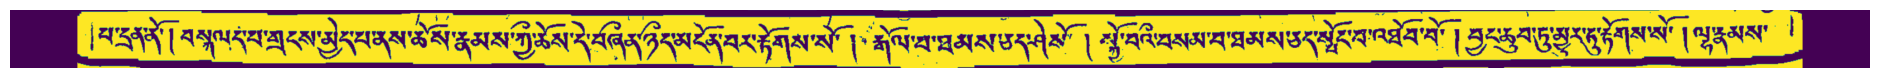

In [ ]:
# check dataloader
test_sample = next(iter(ocr_trainer.test_loader))

test_img = test_sample[0][4].numpy()
test_img = np.transpose(test_img, axes=[1, 2, 0])

show_image(test_img)

In [15]:
# debug start logits for non-zeros
test_sample = next(iter(ocr_trainer.test_loader))
test_logits, gt_labels = ocr_trainer.network.test(test_sample)
pred = np.argmax(test_logits[0], axis=0)
print(pred[:40]) # there should be no leading zeros

[ 99   7   8   7 306   7   7   7   7   7   7 185   7 298 253   7   7   7
   7   7   7   7   7   7   7   7   7 168   7 187   7   7 373  92   7   7
  72   7 221   7]
